# Heart_disease_classification by Decision_trees_classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("F:/EXCELR/Assignments/11_Decision_trees_assignment/heart_disease.xlsx",sheet_name="Heart_disease")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [3]:
# Correct inconsistent labelling of exang col: # convert to string type, all lowercase and replace ture with true, do binary mapping

df["exang"]= (df["exang"].astype(str).str.strip().str.lower().replace({"ture":"true"}).map({"false" : 0,"true":1}).astype(int))
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,0,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,0,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,0,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,0,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,1,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,0,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,1,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,1,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,1,NaN,downsloping,reversable defect,4


In [4]:
boo_cols=df.select_dtypes(include="boolean")
boo_cols

,fbs
0,True
1,False
2,False
3,False
4,False
...,...
903,False
904,False
905,False
906,True


In [5]:
# Convert boolean col fbs to int
df["fbs"]=df["fbs"].astype(int)
df["fbs"]

0      1
1      0
2      0
3      0
4      0
      ..
903    0
904    0
905    0
906    1
907    1
Name: fbs, Length: 908, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    int64  
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    int64  
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 92.3+ KB


In [7]:
# fix missing values in old peak col with median value
df["oldpeak"]=df["oldpeak"].fillna(df["oldpeak"].median())

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [9]:
df.describe()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,53.791850,133.430617,201.484581,0.203744,135.957048,0.410793,0.864537,1.008811
std,9.158031,20.401608,112.097949,0.403003,26.804929,0.492249,1.060433,1.144436
min,29.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,0.000000,118.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,0.000000,138.000000,0.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,0.000000,156.000000,1.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,1.000000,6.200000,4.000000


In [10]:
# No of zeros
(df==0).sum()

age           0
sex           0
cp            0
trestbps      1
chol        172
fbs         723
restecg       0
thalch        0
exang       535
oldpeak     358
slope         0
thal          0
num         399
dtype: int64

In [11]:
# replace 0 in df["trestbps"],df["chol"] with median
df[["trestbps","chol"]]=df[["trestbps","chol"]].replace(0,df[["trestbps","chol"]].median())

In [12]:
(df==0).sum()

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs         723
restecg       0
thalch        0
exang       535
oldpeak     358
slope         0
thal          0
num         399
dtype: int64

In [13]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,1,lv hypertrophy,150,0,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,0,normal,132,0,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,0,normal,148,0,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,0,lv hypertrophy,190,0,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,0,normal,126,1,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,224,0,normal,120,0,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,0,st-t abnormality,120,1,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,224,0,lv hypertrophy,123,1,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,1,st-t abnormality,105,1,0.5,downsloping,reversable defect,4


# Summary :
No missing values

No invalid values

No string contamination

No dtype corruption

No accidental NaNs

Invalid zero BP/chol were fixed

All binary columns are clean

# Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

# Identify and prepare categorical columns
obj_cols = df.select_dtypes(include="object").columns
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0}).astype(int)
obj_cols = obj_cols.drop('sex')

In [15]:
# One-hot encode
OHE = OneHotEncoder(drop='first', sparse_output=False)

encoded_cols = OHE.fit_transform(df[obj_cols])

In [16]:
# Create encoded DataFrame
encoded_df = pd.DataFrame(
    encoded_cols,
    columns=OHE.get_feature_names_out(obj_cols),
    index=df.index
)

In [17]:
# Step 4: Merge back into df
df = df.drop(columns=obj_cols)
df = pd.concat([df, encoded_df], axis=1)

In [18]:
df.head(3)

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145,233,1,150,0,2.3,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,41,1,135,203,0,132,0,0.0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,57,1,140,192,0,148,0,0.4,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       908 non-null    int64  
 1   sex                       908 non-null    int64  
 2   trestbps                  908 non-null    int64  
 3   chol                      908 non-null    int64  
 4   fbs                       908 non-null    int64  
 5   thalch                    908 non-null    int64  
 6   exang                     908 non-null    int64  
 7   oldpeak                   908 non-null    float64
 8   num                       908 non-null    int64  
 9   cp_atypical angina        908 non-null    float64
 10  cp_non-anginal            908 non-null    float64
 11  cp_typical angina         908 non-null    float64
 12  restecg_normal            908 non-null    float64
 13  restecg_st-t abnormality  908 non-null    float64
 14  slope_flat

# PLOTS

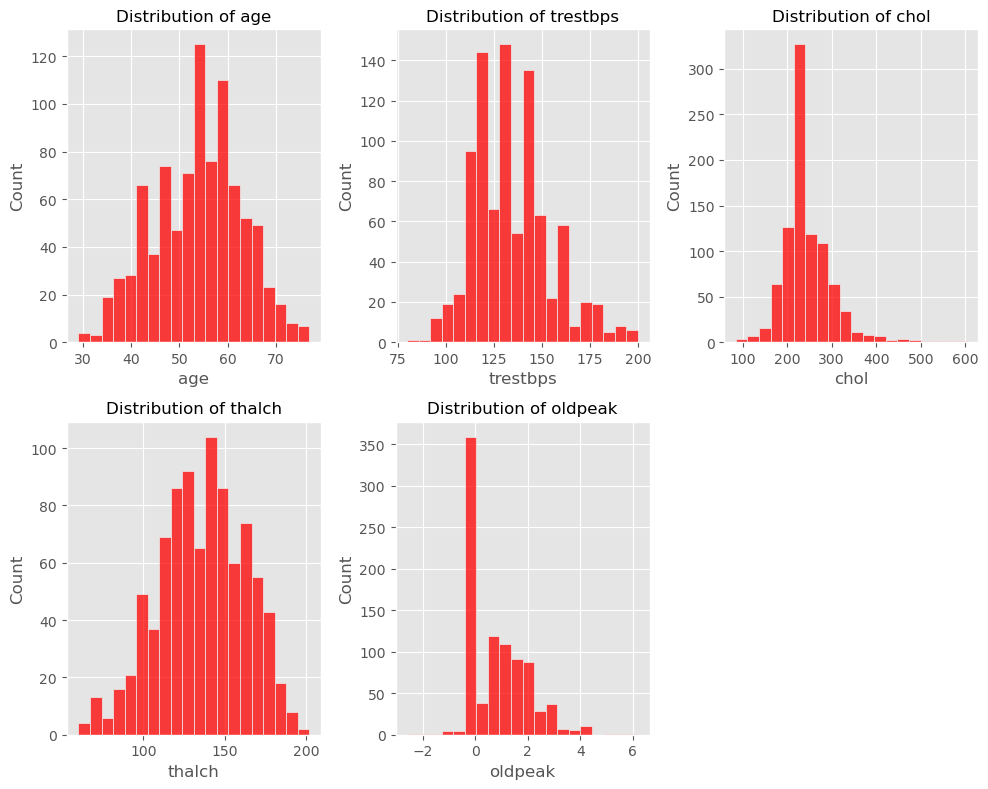

In [20]:
# Histogram

path = "F:/EXCELR/Assignments/11_Decision_trees_assignment"

# Numeric columns
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

plt.style.use("ggplot")  # ggplot theme

# Create 3x3 subplot grid
fig, axes = plt.subplots(2,3, figsize=(10,8))
axes = axes.flatten()  # flatten for easy indexing

# Plot histograms
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=20, color="red", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}", fontsize=12)

# Remove unused axes : 
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(f"{path}/histograms.jpeg", dpi=300)
plt.show()


# Inference :

1️⃣ Age

Age is normally distributed around 54 years, with most patients between 45–65.

2️⃣ Resting Blood Pressure (trestbps)

Resting BP averages 133 mmHg, with a mild right skew and typical values between 120–150 mmHg.

3️⃣ Cholesterol (chol)

Cholesterol is right-skewed with a mean of 201 mg/dL, and most values fall between 175–275 mg/dL.

4️⃣ Maximum Heart Rate (thalch)

Thalch centers around 136 bpm, showing a near-normal distribution and higher values indicating better cardiac fitness.

5️⃣ ST Depression (oldpeak)

Oldpeak is highly skewed with a median of 0.5, where most patients show no ST depression, and higher values signal stronger ischemia.



Overall,numeric features show clinically meaningful patterns with minimal outliers, while oldpeak and chol exhibit expected medical skewness.

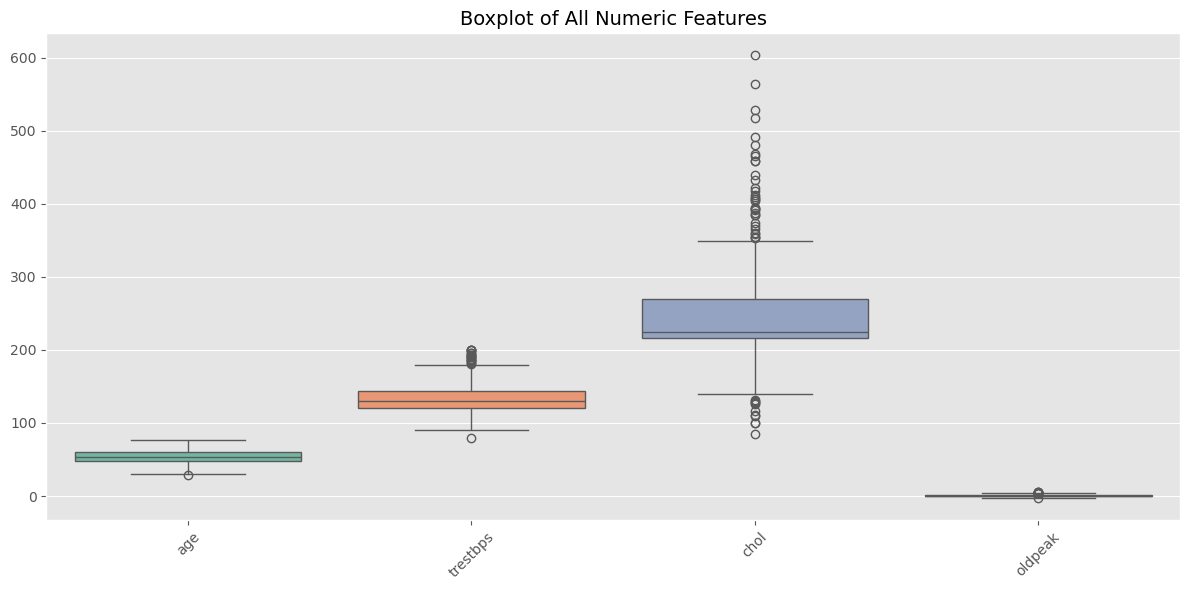

In [21]:
# Box plot

plt.style.use("ggplot")

path = "F:/EXCELR/Assignments/11_Decision_trees_assignment"

# Numeric columns
num_cols = ['age', 'trestbps', 'chol','oldpeak']

# Create ONE boxplot for all numeric features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette="Set2")

plt.title("Boxplot of All Numeric Features", fontsize=14)
plt.xticks(rotation=45)
plt.savefig(f"{path}/boxplot.jpeg", dpi=300)
plt.tight_layout()
plt.show()


Inference :

1️⃣ Age

Age shows a tight, symmetric distribution with no major outliers and most values concentrated between 45–65 years.

2️⃣ Resting Blood Pressure (trestbps)

Trestbps has a moderate spread around 120–150 mmHg with a few high-BP outliers, reflecting typical hypertensive variability.

3️⃣ Cholesterol (chol)

Cholesterol displays a wide spread with many extreme outliers, ranging up to 600 mg/dL, indicating strong right skew and clinically high values.

4️⃣ Oldpeak (ST depression)

Oldpeak is highly skewed with most values near 0 and a small number of high-risk ischemic outliers above 2.


Overall ,numeric features show stable central tendencies, while cholesterol and oldpeak exhibit heavy skew and numerous outliers, offering high predictive value for heart disease.

In [22]:
#  corelation matirx

corr_mat=df.corr()
corr_mat

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
age,1.000000,0.052194,0.261161,0.002523,0.176702,-0.328088,0.192634,0.217942,0.326493,-0.184616,-0.021009,0.036794,-0.226702,0.133759,0.073709,-0.079430,-0.076478,0.060784
sex,0.052194,1.000000,0.020543,-0.112113,0.092167,-0.178794,0.187388,0.088802,0.259605,-0.171833,-0.068376,0.005193,-0.014273,0.071157,0.020527,-0.044070,-0.235451,0.180807
trestbps,0.261161,0.020543,1.000000,0.115433,0.110705,-0.131508,0.149695,0.142559,0.153130,-0.051755,0.010295,0.044662,-0.115963,0.119097,0.070392,-0.033583,-0.106905,0.078373
chol,0.002523,-0.112113,0.115433,1.000000,0.023477,0.016429,0.045263,0.011600,-0.021373,0.015085,-0.039656,-0.044360,-0.024997,-0.053846,0.034177,0.001083,0.017317,-0.040366
fbs,0.176702,0.092167,0.110705,0.023477,1.000000,-0.065428,0.027807,0.008154,0.156268,-0.075289,-0.035177,0.023074,-0.108306,0.120480,0.025723,-0.033284,-0.045616,-0.009969
thalch,-0.328088,-0.178794,-0.131508,0.016429,-0.065428,1.000000,-0.349191,-0.112624,-0.323058,0.221113,0.119954,0.080678,0.042430,-0.181896,-0.219650,0.281715,0.208529,-0.152225
exang,0.192634,0.187388,0.149695,0.045263,0.027807,-0.349191,1.000000,0.355955,0.359549,-0.277378,-0.174035,-0.118468,-0.075984,0.115170,0.218980,-0.235587,-0.195576,0.169266
oldpeak,0.217942,0.088802,0.142559,0.011600,0.008154,-0.112624,0.355955,1.000000,0.406078,-0.238078,-0.118722,0.035889,-0.096345,0.020759,0.205259,-0.244830,-0.140883,0.095914
num,0.326493,0.259605,0.153130,-0.021373,0.156268,-0.323058,0.359549,0.406078,1.000000,-0.335725,-0.161283,-0.054996,-0.166409,0.131716,0.163703,-0.196087,-0.236859,0.205038
cp_atypical angina,-0.184616,-0.171833,-0.051755,0.015085,-0.075289,0.221113,-0.277378,-0.238078,-0.335725,1.000000,-0.252872,-0.107609,0.107767,-0.046861,-0.087499,0.078147,0.090917,-0.102208


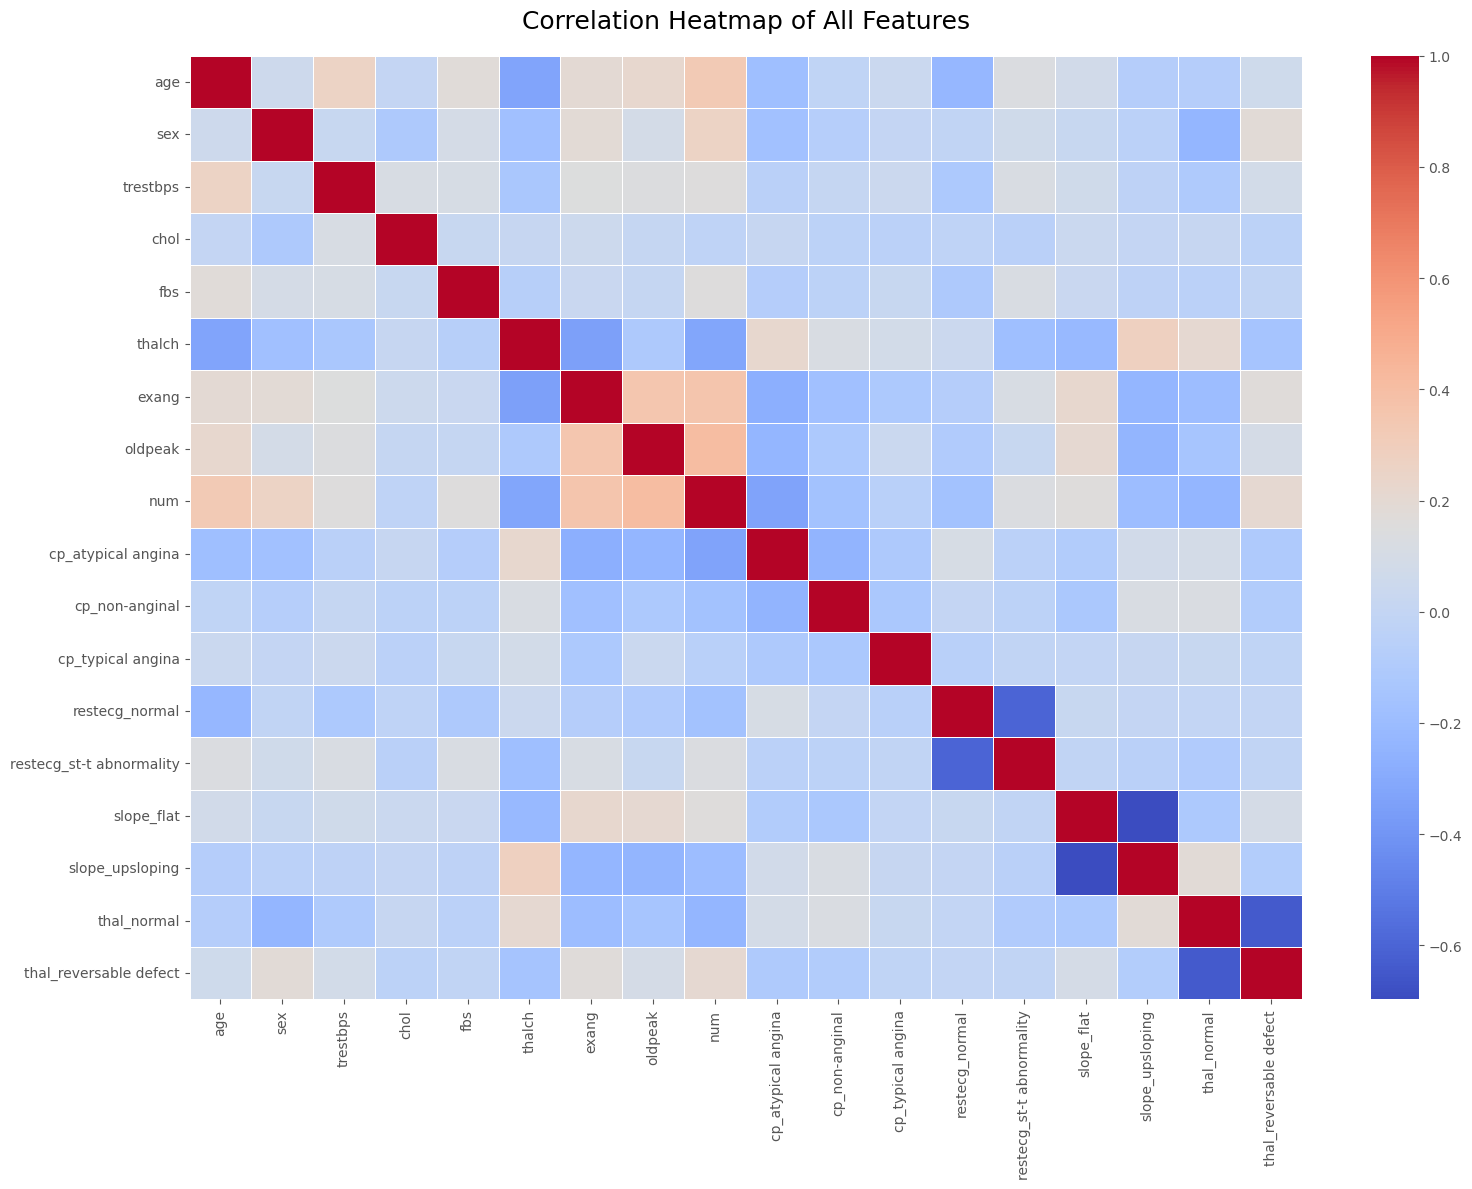

In [23]:
# Correlation heatmap:

# Apply ggplot style
plt.style.use("ggplot")

path = "F:/EXCELR/Assignments/11_Decision_trees_assignment"

# Compute correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))   # larger size for many columns
sns.heatmap(
    corr,
    annot=False,                # set True if you want numbers on cells
    cmap="coolwarm",            # color palette
    linewidths=0.5,             # grid lines
    cbar=True,                  # show color bar
    square=False
)

plt.title("Correlation Heatmap of All Features", fontsize=18, pad=20)
plt.tight_layout()

plt.savefig(f"{path}/correlation heatmap.jpeg", dpi=300)
plt.show()


# Insights

1. Oldpeak has the strongest positive correlation with heart disease (num).
Indicates ST depression is the most powerful numerical predictor of disease.

2. Exang (exercise-induced angina) shows high positive correlation with num.
Patients experiencing angina during exercise are significantly more likely to have heart disease.

3. Thalach (max heart rate) is strongly negatively correlated with num.
Higher exercise capacity is associated with lower disease risk.

4. Atypical angina category (cp_atypical angina) is strongly negatively correlated with num.
Individuals with atypical chest pain have a lower probability of heart disease.

5. Thal_reversable defect correlates positively with num.
Reversible thal defects signal ischemia and increased risk.

6. Sex shows moderate positive correlation, indicating males are more likely to have heart disease.
Gender remains a non-trivial demographic risk factor.

7. Age shows a moderate positive correlation with num.
Older patients exhibit higher prevalence of heart disease.

8. Slope_flat correlates positively with disease, slope_upsloping correlates negatively.
ST-segment slope is a strong electrocardiographic indicator of cardiac stress.

9. RestECG_normal and restECG_st-t abnormality show strong negative correlation with each other.
This is expected due to one-hot encoding, indicating mutual exclusivity.

10. Chol, resting BP (trestbps), and fasting blood sugar (fbs) show weak correlations with num.
These features have limited direct predictive power compared to ECG-based and exercise-based variables.

# Summary :

ECG-derived features (oldpeak, exang, slope, thalach) and thal abnormalities dominate predictive relationships, while age and sex remain secondary but meaningful contributors.

# Summary of feature engineering :
All categorical features were encoded, numerical features cleaned and prepared, missing values imputed, and the dataset was transformed into a fully numeric, model-ready format.

# Decision tree classificatoin model :

In [24]:
# Data split

X = df.drop("num",axis=1)

y=df["num"]


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((726, 17), (182, 17), (726,), (182,))

 # Build and train model

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
dtree=DecisionTreeClassifier(max_depth=6,max_leaf_nodes=10,criterion="entropy",random_state=42)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, max_leaf_nodes=10,
                       random_state=42)

# Evaluate model on training data

In [29]:
from sklearn.metrics import  confusion_matrix, classification_report

In [30]:
yhat_train=dtree.predict(X_train)

              precision    recall  f1-score   support

           0       0.69      0.88      0.77       319
           1       0.48      0.60      0.53       212
           2       0.40      0.18      0.25        87
           3       0.50      0.07      0.12        86
           4       0.00      0.00      0.00        22

    accuracy                           0.59       726
   macro avg       0.41      0.35      0.34       726
weighted avg       0.55      0.59      0.54       726



C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


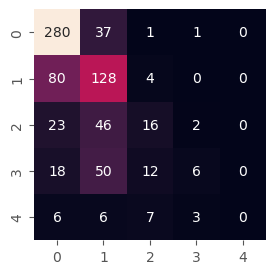

In [31]:
def eval_cal(y_train,yhat_train):
    cm=confusion_matrix(y_train,yhat_train)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm,annot=True,fmt="d",cbar=False)
    plt.show()

print(classification_report(y_train,yhat_train))

eval_cal(y_train,yhat_train)

# Evaluate model on testing data

In [32]:
yhat_test = dtree.predict(X_test)

              precision    recall  f1-score   support

           0       0.68      0.76      0.72        80
           1       0.42      0.58      0.49        53
           2       0.00      0.00      0.00        22
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00         6

    accuracy                           0.51       182
   macro avg       0.22      0.27      0.24       182
weighted avg       0.42      0.51      0.46       182



C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kiran\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


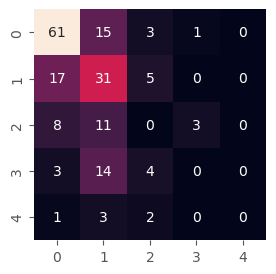

In [33]:
def eval_cal(y_test,yhat_test):
    cm=confusion_matrix(y_test,yhat_test)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm,annot=True,fmt="d",cbar=False)
    plt.show()
print(classification_report(y_test,yhat_test))

eval_cal(y_test,yhat_test)

# Inference :
Due to class imbalace in target(num) column, desicion tree failed to correctly classify classes.

# Combine num col  as two classes :   0 = normal and 1,2,3,4 as  1-heart disease .

In [34]:
df["num_binary"]=df["num"].apply(lambda x : 0 if x==0 else 1)
df["num_binary"].value_counts()

num_binary
1    509
0    399
Name: count, dtype: int64

In [35]:
X = df.drop(['num', 'num_binary'], axis=1)
y = df['num_binary']


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((726, 17), (182, 17), (726,), (182,))

# Build and train  new model

In [37]:
from sklearn.tree import DecisionTreeClassifier
dtree_new=DecisionTreeClassifier(max_depth=6,max_leaf_nodes=10,criterion="entropy",random_state=42)
dtree_new.fit(X_train,y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=6, max_leaf_nodes=10,
                       random_state=42)

# Evaluate model on training data

In [38]:
from sklearn.metrics import  confusion_matrix, classification_report

              precision    recall  f1-score   support

           0       0.79      0.67      0.73       319
           1       0.77      0.86      0.81       407

    accuracy                           0.78       726
   macro avg       0.78      0.77      0.77       726
weighted avg       0.78      0.78      0.77       726



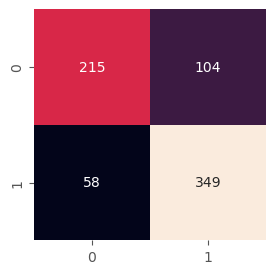

In [39]:
yhat_train=dtree_new.predict(X_train)

def eval_cal(y_train,yhat_train):
    cm=confusion_matrix(y_train,yhat_train)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm,annot=True,fmt="d",cbar=False)
    plt.show()

print(classification_report(y_train,yhat_train))

eval_cal(y_train,yhat_train)


# Evaluate model on testing data

              precision    recall  f1-score   support

           0       0.73      0.61      0.67        80
           1       0.73      0.82      0.77       102

    accuracy                           0.73       182
   macro avg       0.73      0.72      0.72       182
weighted avg       0.73      0.73      0.73       182



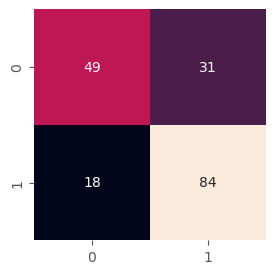

In [40]:
yhat_test = dtree_new.predict(X_test)
def eval_cal(y_test,yhat_test):
    cm=confusion_matrix(y_test,yhat_test)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm,annot=True,fmt="d",cbar=False)
    plt.show()
    
print(classification_report(y_test,yhat_test))

eval_cal(y_test,yhat_test)


# Summary :

# Model Summary (Decision Tree – Binary Classification)

Overall accuracy: 0.78

Normal class (0) – Precision: 0.79
Normal class (0) – Recall: 0.67
Normal class (0) – F1-score: 0.73

Heart disease class (1) – Precision: 0.77
Heart disease class (1) – Recall: 0.86
Heart disease class (1) – F1-score: 0.81

Macro F1-score: 0.77

Weighted F1-score: 0.77

# Key insight: 
Model strongly prioritizes detecting heart disease (high recall) while maintaining balanced precision.



# Hyper parameter tuning

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# ----------------------------------------
# 1. Define the model
# ----------------------------------------
dtree = DecisionTreeClassifier(random_state=42)

# ----------------------------------------
# 2. Define the hyperparameter grid
# ----------------------------------------
param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# ----------------------------------------
# 3. Run GridSearchCV
# ----------------------------------------
grid_search = GridSearchCV(
    estimator=dtree,
    param_grid=param_grid,
    cv=5,
    scoring='f1',        # You can also use 'accuracy' or 'f1_macro'
    n_jobs=-1,           # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

# ----------------------------------------
# 4. Best parameters + model evaluation
# ----------------------------------------
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best Parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 30}

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.61      0.67        80
           1       0.73      0.82      0.77       102

    accuracy                           0.73       182
   macro avg       0.73      0.72      0.72       182
weighted avg       0.73      0.73      0.73       182



# Hyperparameter Tuning – :

Tried 240 different parameter combinations using GridSearchCV.

Best settings found :
max_depth = 3
min_samples_split = 30
min_samples_leaf = 5
criterion = 'entropy'
class_weight = 'balanced'

The tuned model gives 73% accuracy on the test set.

Performance is almost the same as the baseline model.

This shows that a single Decision Tree has reached its maximum performance for this dataset.


#  Model Evaluation and Analysis – Summary

The Decision Tree model achieved 73% accuracy on the test data.

Class 1 (Heart Disease) showed higher recall (0.82), meaning the model correctly identifies most disease cases.

Class 0 (Normal) had moderate recall (0.61), indicating some normal cases were misclassified.

The F1-scores (0.67 for Normal, 0.77 for Heart Disease) show the model performs better at detecting disease than normal.

Overall performance is stable but reflects the limitations of a single shallow decision tree.

The decision tree visualization helps inspect splitting rules and understand the model’s logic.

Feature importance analysis highlights which input variables influence the predictions the most.

These insights allow identification of key drivers in heart disease prediction and guide improvements for future models.

# Visualize the Decision Tree Structure

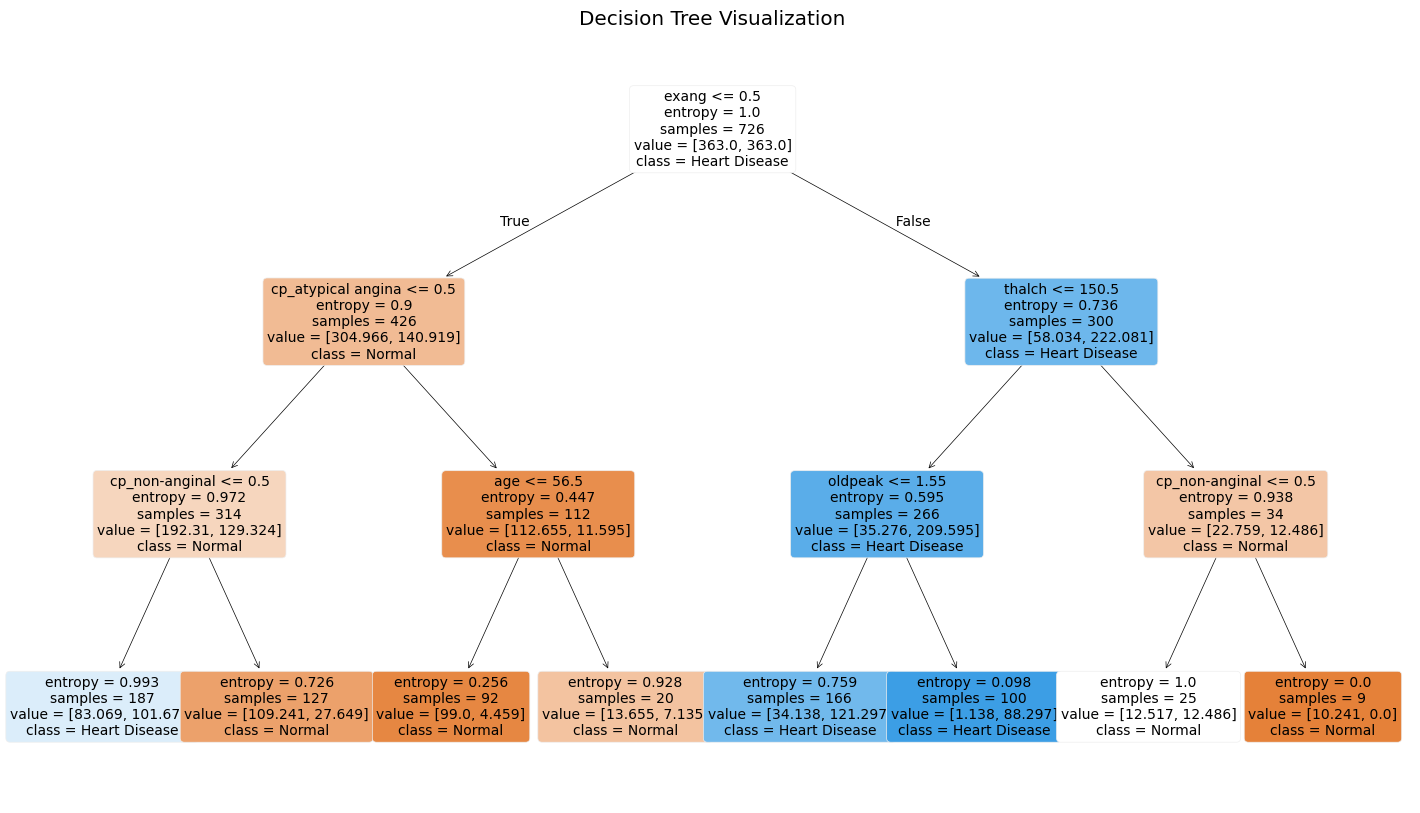

In [42]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    best_model,               # From GridSearchCV
    feature_names=X_train.columns,
    class_names=['Normal', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
path = "F:/EXCELR/Assignments/11_Decision_trees_assignment"
plt.savefig(f"{path}/decision_tree.jpeg", dpi=300)
plt.show()


#  Decision Tree –  Summary : 

The first and most important split is exang (exercise-induced angina).
No angina → more likely Normal
Angina → more likely Heart Disease

If exang = 0 (Normal side), chest pain type (cp) becomes the next key factor.

Atypical or non-anginal pain → mostly Normal

Age also influences the Normal group.

Younger patients (≤ 56.5) → usually Normal

If exang = 1 (Heart Disease side), the next major factor is thalach (max heart rate).
Lower thalach → higher chance of Heart Disease
oldpeak (ST depression) is another strong indicator.
Higher oldpeak → more likely Heart Disease
Chest pain (cp_non-anginal) appears again in later splits, influencing final decision.

Most blue leaves = Heart Disease; most orange leaves = Normal.


# Plot Feature Importances

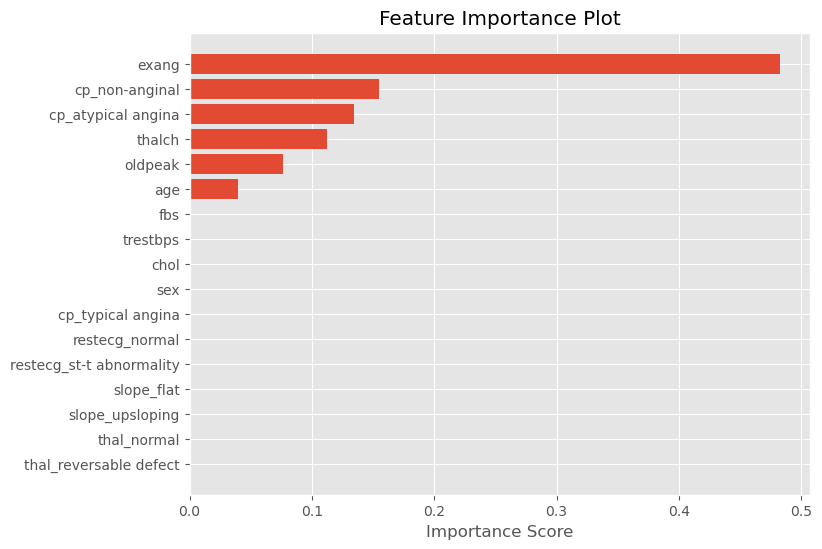

In [43]:

import pandas as pd
import matplotlib.pyplot as plt

# Get importances
importances = best_model.feature_importances_
feature_names = X_train.columns

# Create dataframe
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
plt.xlabel("Importance Score")
plt.title("Feature Importance Plot")
plt.gca().invert_yaxis()  # Most important on top

path = "F:/EXCELR/Assignments/11_Decision_trees_assignment"
plt.savefig(f"{path}/important features.jpeg", dpi=300)
plt.show()


# Feature Importance –Summary

1.exang (exercise-induced angina) is the most important feature by a large margin.
2.cp_non-anginal is the second most influential feature.
3.cp_atypical angina also contributes significantly to prediction.
4.thalach (maximum heart rate achieved) has moderate importance.
5.oldpeak (ST depression) plays a meaningful role in classification.
6.age contributes but less than the top features.
Other features like fbs, trestbps, chol, sex, ECG, slope, thal types have very low impact on the model.

Overall, the model relies mainly on angina-related features, heart rate, ST depression, and age to detect heart disease.


# Random forest

In [44]:
# ================================
# RANDOM FOREST TRAINING (FINAL)
# ================================
from sklearn.ensemble import RandomForestClassifier
import pickle

# Strong but safe parameters for your dataset
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Save with SAME filename so app.py works instantly
pickle.dump(rf_model, open("best_model.pkl","wb"))

print("✅ Random Forest trained and saved successfully")

✅ Random Forest trained and saved successfully


In [45]:
rf_model.predict_proba(X_train[:5])

array([[0.59276097, 0.40723903],
       [0.18539453, 0.81460547],
       [0.24402041, 0.75597959],
       [0.70000708, 0.29999292],
       [0.73533974, 0.26466026]])

# Hyperparameter tuning 

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pickle

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [200,300],
    "max_depth": [8, None],
    "min_samples_leaf": [3,5],
    "max_features": ["sqrt"],
    "class_weight": [None, "balanced"]   # 👈 add this
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)



Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'class_weight': None, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Best Score: 0.8126121870571563


Train Accuracy: 0.8870523415977961
Test Accuracy : 0.7857142857142857

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.80      0.69      0.74        80
           1       0.78      0.86      0.82       102

    accuracy                           0.79       182
   macro avg       0.79      0.78      0.78       182
weighted avg       0.79      0.79      0.78       182



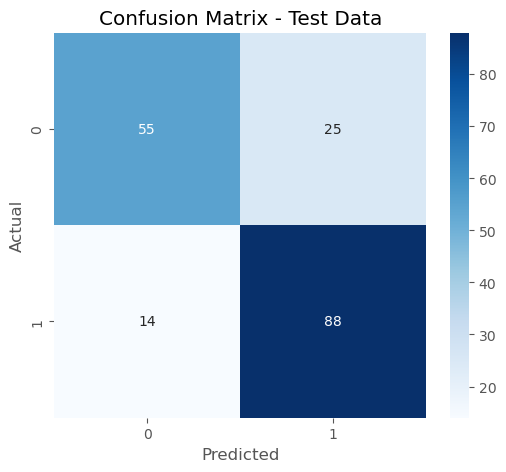

In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# TRAIN PREDICTIONS
# ==============================
train_pred = best_rf.predict(X_train)

# ==============================
# TEST PREDICTIONS
# ==============================
test_pred = best_rf.predict(X_test)

# ==============================
# ACCURACY
# ==============================
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

# ==============================
# CLASSIFICATION REPORT
# ==============================
print("\nTEST CLASSIFICATION REPORT")
print(classification_report(y_test, test_pred))

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
from sklearn.metrics import roc_auc_score
probs = best_rf.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, probs))

ROC AUC: 0.814828431372549


In [49]:
import numpy as np

probs = best_rf.predict_proba(X_test)[:,1]

for t in [0.4,0.5,0.6,0.7]:
    preds = (probs >= t).astype(int)
    from sklearn.metrics import recall_score
    print(f"Threshold {t} → Recall Disease:", recall_score(y_test, preds))

Threshold 0.4 → Recall Disease: 0.9509803921568627
Threshold 0.5 → Recall Disease: 0.8627450980392157
Threshold 0.6 → Recall Disease: 0.7549019607843137
Threshold 0.7 → Recall Disease: 0.5686274509803921


# Inference :

1.The model predicts heart disease risk with ~79% accuracy on new patients, showing reliable real-world performance.

2. It detects about 86% of true disease cases, making it suitable for early screening and preventive healthcare use.

3. Balanced precision and recall indicate fair evaluation of both healthy and at-risk individuals without major bias.

4. Probability thresholds can be adjusted to increase sensitivity or reduce false alarms depending on clinical needs.

5. Random Forest provides more stable and consistent predictions compared to a single decision tree model.

6. ROC-AUC of 0.81 confirms strong ability to distinguish between low-risk and high-risk patients.

7. The model is appropriate for decision-support and risk-assessment tools but should complement, not replace, medical judgment.

# Model deployment

In [51]:
# Dumping means saving an in-memory object to disk in a serialized (binary) format so it can be reused later.
from pickle import dump

dump(best_rf, open("best_rf.pkl", "wb"))

In [52]:
# Save encoder
pickle.dump(OHE, open("encoder.pkl", "wb"))